Columns in dataset: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'income_level']
Using income_level as target.

--- Training AdaBoost ---
Accuracy Score: 0.8327


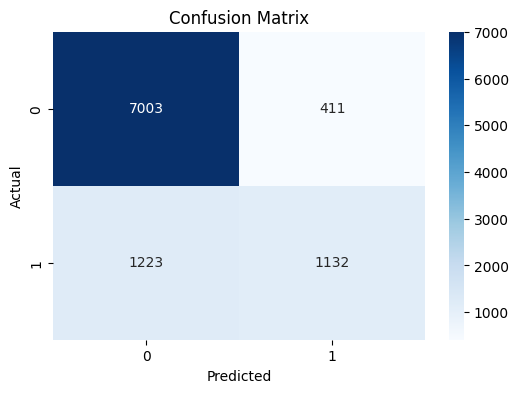

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df = pd.read_csv('income.csv')
print('Columns in dataset:', df.columns.tolist())

# 2. Preprocessing
# Based on your file, the target is likely 'income_level'
target_col = 'income_level' if 'income_level' in df.columns else df.columns[-1]
print(f'Using {target_col} as target.')

# Encode categorical variables
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# Split features and target
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training and Evaluation
print('\n--- Training AdaBoost ---')
abc = AdaBoostClassifier(n_estimators=50, random_state=42)
abc.fit(X_train, y_train)
y_pred = abc.predict(X_test)

print(f'Accuracy Score: {accuracy_score(y_test, y_pred):.4f}')
cm = confusion_matrix(y_test, y_pred)

# 4. Visualize Results
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()